# 01 EDA
Use this notebook for exploratory data analysis only. Move reusable logic into `src/`.

In [2]:
import pandas as pd
df = pd.read_csv('../data/processed/train.csv')
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 01 — Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset *before* touching any model.

EDA answers four questions:
1. What does the data look like? (shape, types, samples)
2. Is the target balanced?
3. Are there missing values or data quality issues?
4. Which features look informative?

> **Rule:** No model code here. Findings drive decisions in `02_feature_experiments.ipynb` and ultimately in `src/features/preprocess.py`.

In [3]:
from pathlib import Path
import pandas as pd

# Load training data
data_path = '../data/processed/titanic_bakeoff_train_1.csv'
df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded data from: ../data/processed/titanic_bakeoff_train_1.csv
Shape: (200, 8)


,target,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.0,0,0,7.2500,S
1,1,1,female,29.0,1,0,71.2833,C
2,1,3,female,22.0,0,0,7.9250,S
3,1,1,male,48.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes.value_counts())
print("\nAll columns:", df.columns.tolist())
df.describe().T.round(2)

Shape: (200, 8)

Column dtypes:
int64      4
str        2
float64    2
Name: count, dtype: int64

All columns: ['target', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,count,mean,std,min,25%,50%,75%,max
target,200.0,0.49,0.50,0.00,0.00,0.00,1.00,1.00
Pclass,200.0,2.22,0.84,1.00,1.00,2.00,3.00,3.00
Age,171.0,26.74,12.43,1.00,18.50,27.00,34.00,65.00
SibSp,200.0,0.36,0.60,0.00,0.00,0.00,1.00,2.00
Parch,200.0,0.32,0.64,0.00,0.00,0.00,0.00,2.00
Fare,200.0,27.74,31.30,2.53,7.54,13.48,34.36,177.25


## Step 2 — Target Distribution

For a classifier the first question is always: **is the target balanced?**

Imbalanced targets make accuracy misleading — always check class proportions first.

Class counts:
 target
0    102
1     98

Class %:
 target
0    51.0
1    49.0


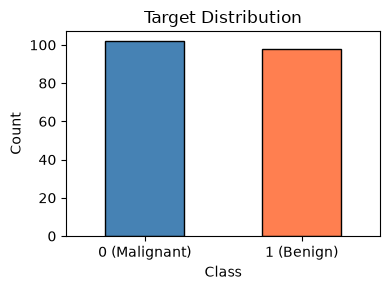

In [5]:
import matplotlib.pyplot as plt

counts = df['target'].value_counts()
pct    = df['target'].value_counts(normalize=True).mul(100).round(1)

print("Class counts:\n", counts.to_string())
print("\nClass %:\n", pct.to_string())

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Target Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['0 (Malignant)', '1 (Benign)'], rotation=0)
plt.tight_layout()
plt.show()

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

report = (
    pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
    .query('missing_count > 0')
)

if report.empty:
    print("No missing values found.")
    print("The imputers in src/features/preprocess.py act as a safety net for future data.")
else:
    print(report.sort_values('missing_%', ascending=False))

     missing_count  missing_%
Age             29       14.5


Numeric features    : 5
Categorical features: 2


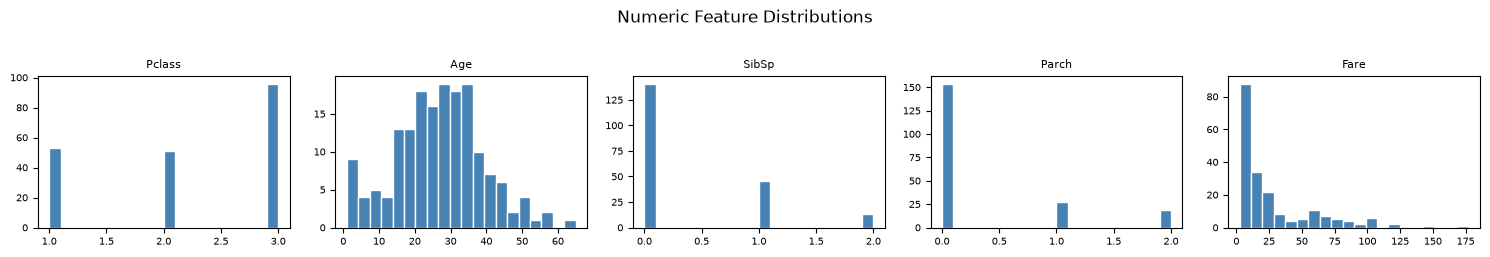


Observation: features have very different scales.
This is why scale_numeric: true is set in configs/features/default.yaml


In [7]:
feature_cols  = [c for c in df.columns if c != 'target']
numeric_cols  = df[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols      = [c for c in feature_cols if c not in numeric_cols]

print(f"Numeric features    : {len(numeric_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# Histogram grid
n_cols = 5
n_rows = -(-len(numeric_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation: features have very different scales.")
print("This is why scale_numeric: true is set in configs/features/default.yaml")

## Step 5 — Correlation Analysis

High inter-feature correlation means redundant information. This informs whether to add columns to `drop_columns` in `configs/features/default.yaml`.

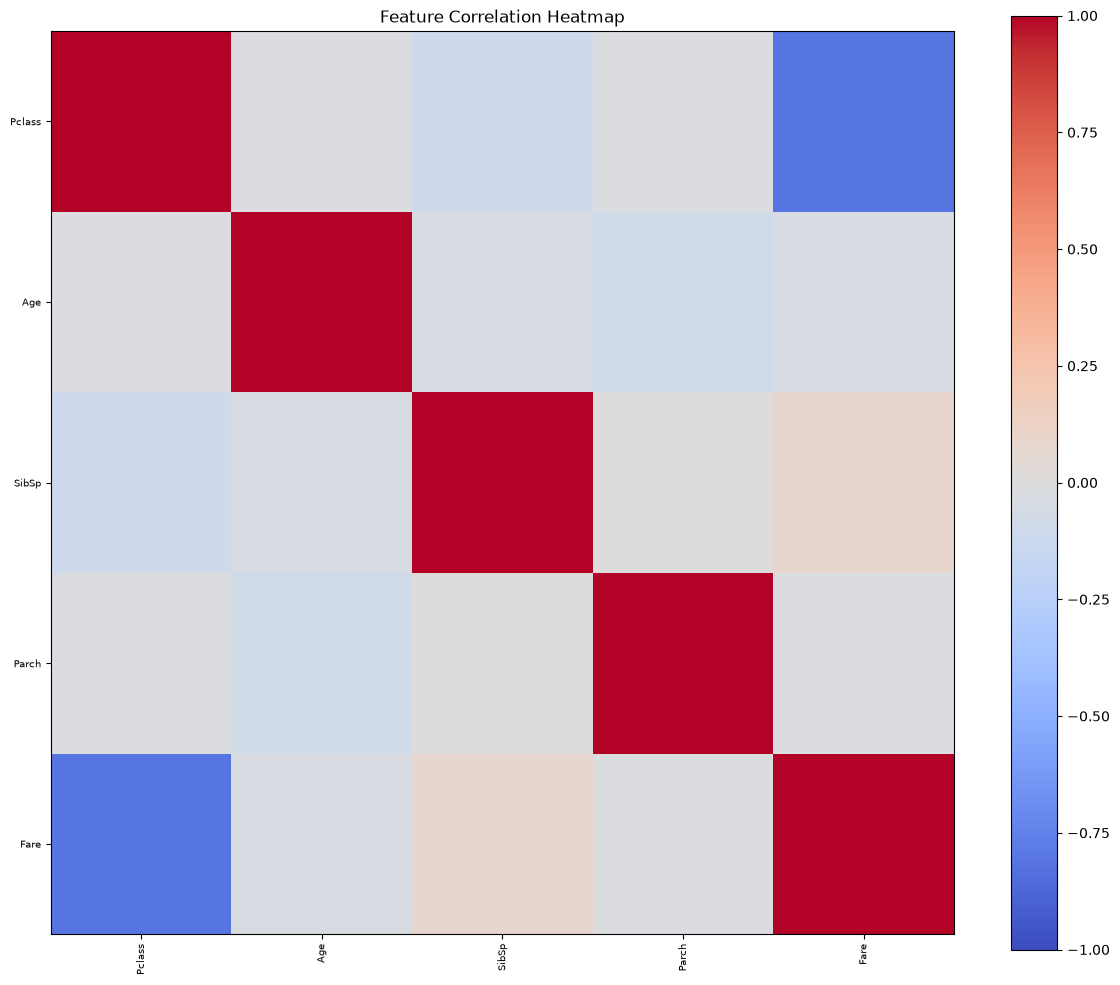

Feature pairs with |correlation| >= 0.9:
Empty DataFrame
Columns: [feature_1, feature_2, corr]
Index: []


In [8]:
import numpy as np

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print highly correlated pairs
threshold = 0.9
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
    .query('abs(corr) >= @threshold')
    .sort_values('corr', ascending=False)
)
print(f"Feature pairs with |correlation| >= {threshold}:")
print(high_corr.to_string(index=False))

## Step 6 — EDA Summary & Decisions

Map every finding to an action in the repo:

| Finding | Decision | Where in repo |
|---|---|---|
| No missing values | Imputers are a safety net | `src/features/preprocess.py` |
| Features on very different scales | `scale_numeric: true` | `configs/features/default.yaml` |
| No categorical columns (this dataset) | OHE branch ready for future data | `src/features/preprocess.py` |
| Highly correlated feature pairs | Candidates for `drop_columns` | `configs/features/default.yaml` |
| Slightly imbalanced target | Use `roc_auc`, not just accuracy | `src/eval/metrics.py` |

> **Key principle:** Every EDA decision must be traceable to a line of config or code — not buried in a notebook.

In [9]:
!pip install pytz;
import datetime, pytz; 
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Current Time in IST: 2026-08-13 12:15:03
